## Why this visualization matters

The final proposal contains only a small number of stations, so distance and territorial spread become especially important. A Voronoi view helps make that visible. It shows not only where the stations are located, but also how their influence is distributed across the study area, which is useful for discussing network sparsity, corridor coverage, and remaining weak spots.

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Input from Notebook 5
file2_path = "/content/File 2.csv"

if not os.path.exists(file2_path):
    raise FileNotFoundError("Upload or generate /content/File 2.csv first.")

file2 = pd.read_csv(file2_path)

required_cols = [
    "location_id",
    "latitude",
    "longitude",
    "route_segment",
    "n_chargers_proposed",
    "grid_status"
]

missing = [c for c in required_cols if c not in file2.columns]
if missing:
    raise ValueError(f"Missing required columns in File 2: {missing}")

# GeoDataFrame in WGS84
stations_gdf = gpd.GeoDataFrame(
    file2.copy(),
    geometry=gpd.points_from_xy(file2["longitude"], file2["latitude"]),
    crs="EPSG:4326"
)

# Project to metric CRS for Voronoi work
stations_proj = stations_gdf.to_crs("EPSG:25830")

print("Selected stations:", len(stations_gdf))
print("CRS (WGS84):", stations_gdf.crs)
print("CRS (projected):", stations_proj.crs)

display(stations_gdf.head())

Selected stations: 12
CRS (WGS84): EPSG:4326
CRS (projected): EPSG:25830


,location_id,latitude,longitude,route_segment,n_chargers_proposed,grid_status,geometry
0,IBE_001,40.013136,-2.199991,N-420,4,Sufficient,POINT (-2.19999 40.01314)
1,IBE_002,38.867801,-4.794636,N-502,4,Sufficient,POINT (-4.79464 38.8678)
2,IBE_003,41.339153,-5.722461,A-66,4,Sufficient,POINT (-5.72246 41.33915)
3,IBE_004,38.465306,-0.583200,A-7,3,Sufficient,POINT (-0.5832 38.46531)
4,IBE_005,42.470048,-6.873236,N-120,3,Sufficient,POINT (-6.87324 42.47005)


At this stage, the notebook is working only with the final proposed stations from File 2. This is important because the Voronoi diagram should describe the spatial logic of the final proposal, not the larger intermediate candidate universe.

## Define the study area for clipping

Raw Voronoi cells extend infinitely at the edges, so they need to be clipped to a meaningful area. In this notebook, the clipping boundary is based on the interurban mobility backbone so that the service territories remain tied to the actual study scope rather than to an arbitrary outer shape.

In [5]:
import os
import geopandas as gpd

backbone_path = "/content/mobility_backbone.gpkg"

if not os.path.exists(backbone_path):
    raise FileNotFoundError("Upload mobility_backbone.gpkg to /content first.")

backbone = gpd.read_file(backbone_path).to_crs("EPSG:25830")

# Sample a simpler study area from the backbone bounds
xmin, ymin, xmax, ymax = backbone.total_bounds

study_area = gpd.GeoDataFrame(
    geometry=[backbone.geometry.union_all().convex_hull.buffer(20000)],
    crs="EPSG:25830"
)

print("Using simplified backbone-based study area.")
display(study_area)

Using simplified backbone-based study area.


,geometry
0,"POLYGON ((295660.231 3953739.384, 293670.398 3..."


The clipping area keeps the Voronoi visualization tied to the interurban study scope. This matters because the goal is not to partition empty space arbitrarily, but to approximate how the final proposed network is distributed across the territory it is meant to serve.

## Build Voronoi service territories

Using the final proposed stations, this step creates Voronoi cells as an approximate nearest-station partition of space. These polygons are not part of the core optimization method, but they help visualize how the final proposal is distributed geographically.

In [6]:
from shapely.ops import voronoi_diagram

# Use the study area boundary to bound the Voronoi construction
envelope = study_area.geometry.iloc[0]

points_geom = stations_proj.geometry.union_all()
vor = voronoi_diagram(points_geom, envelope=envelope)

voronoi_polys = gpd.GeoDataFrame(
    geometry=list(vor.geoms),
    crs="EPSG:25830"
)

# Clip to the buffered backbone study area
voronoi_tagged_base = gpd.overlay(voronoi_polys, study_area, how="intersection")

print("Voronoi polygons created after clipping:", len(voronoi_tagged_base))
display(voronoi_tagged_base.head())

Voronoi polygons created after clipping: 12


,geometry
0,"POLYGON ((230630.729 4676557.709, 198219.415 4..."
1,"POLYGON ((230630.729 4676557.709, 377232.135 4..."
2,"POLYGON ((57902.099 4401965.367, 149912.768 43..."
3,"POLYGON ((404704.443 4574819.252, 57902.099 44..."
4,"POLYGON ((462479.401 4538511.22, 404704.443 45..."


In [7]:
# Spatially match each polygon to the nearest final station
voronoi_tagged = gpd.sjoin_nearest(
    voronoi_tagged_base,
    stations_proj[
        ["location_id", "route_segment", "n_chargers_proposed", "grid_status", "geometry"]
    ],
    how="left",
    distance_col="dist_to_station_m"
).drop(columns=["index_right"], errors="ignore")

print("Tagged Voronoi polygons:", len(voronoi_tagged))
display(
    voronoi_tagged[
        ["location_id", "route_segment", "n_chargers_proposed", "grid_status", "dist_to_station_m", "geometry"]
    ].head()
)

Tagged Voronoi polygons: 12


,location_id,route_segment,n_chargers_proposed,grid_status,dist_to_station_m,geometry
0,IBE_005,N-120,3,Sufficient,0.0,"POLYGON ((230630.729 4676557.709, 198219.415 4..."
1,IBE_007,A-66,2,Congested,0.0,"POLYGON ((230630.729 4676557.709, 377232.135 4..."
2,IBE_010,N-630,2,Congested,0.0,"POLYGON ((57902.099 4401965.367, 149912.768 43..."
3,IBE_003,A-66,4,Sufficient,0.0,"POLYGON ((404704.443 4574819.252, 57902.099 44..."
4,IBE_011,N-120,2,Congested,0.0,"POLYGON ((462479.401 4538511.22, 404704.443 45..."


Each Voronoi polygon is linked to the final station that is nearest within the projected study area. This gives a simple visual approximation of each station’s spatial influence, helping reveal whether the final proposal is evenly distributed or whether some stations appear responsible for much larger territories than others.

## Spatial interpretation of the final proposal

This map adds a supporting spatial view of the final network. The Voronoi polygons approximate the area that is closest to each proposed station, helping show whether the final proposal is broadly distributed or whether some stations appear responsible for much larger territories than others.

### Why this visualization matters

The final proposal contains only a small number of stations, so distance and territorial spread become especially important. A Voronoi view helps make that visible. It shows not only where the stations are located, but also how their influence is distributed across the study area, which is useful for discussing network sparsity, corridor coverage, and remaining weak spots.

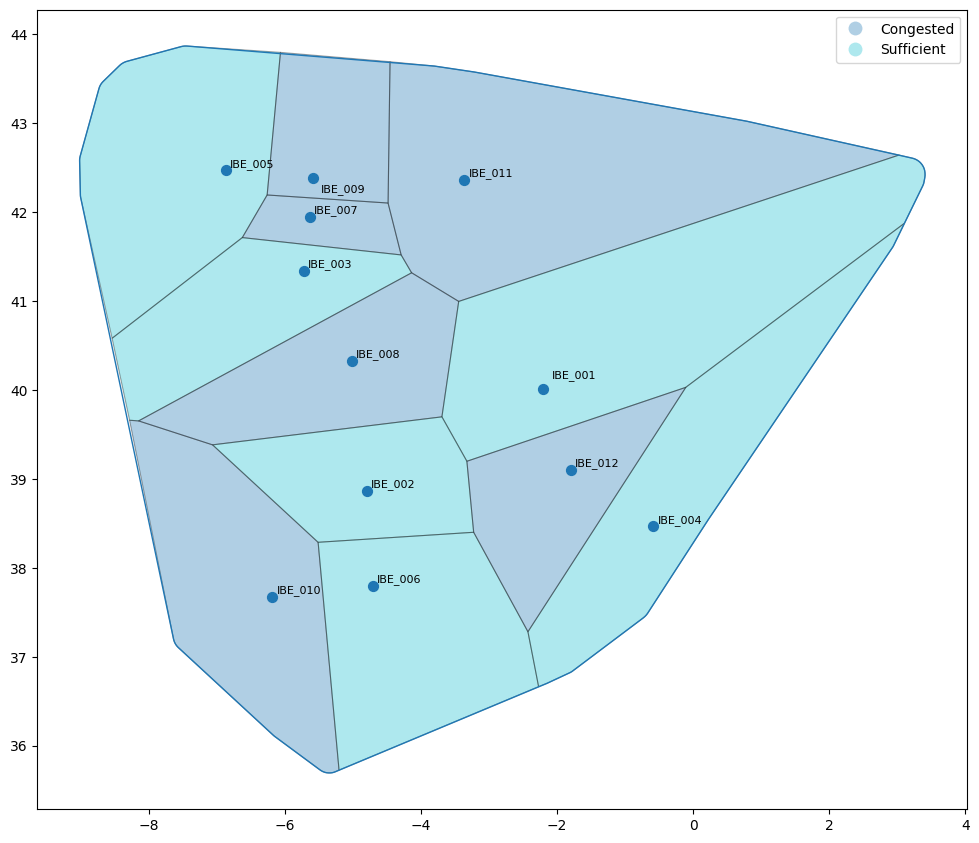

In [8]:
# Convert back to WGS84 for easier plotting / export if needed
voronoi_wgs84 = voronoi_tagged.to_crs("EPSG:4326")
study_area_wgs84 = study_area.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(12, 12))

# Study area outline
study_area_wgs84.boundary.plot(ax=ax, linewidth=1)

# Voronoi polygons
voronoi_wgs84.plot(
    ax=ax,
    column="grid_status",
    legend=True,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.8
)

# Final stations
stations_gdf.plot(
    ax=ax,
    markersize=50,
    marker="o"
)

# Label each station
for _, row in stations_gdf.iterrows():
    dx, dy = 3, 3

    if row["location_id"] == "IBE_001":
        dx, dy = 6, 8
    elif row["location_id"] == "IBE_009":
        dx, dy = 6, -10

    ax.annotate(
        row["location_id"],
        (row.geometry.x, row.geometry.y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8
    )

## What this notebook tells us

This Voronoi view provides a supporting spatial interpretation of the final proposal by approximating the territory closest to each selected station. The main insight is that the final network is geographically sparse and uneven: some stations appear responsible for much larger areas than others, while only a small subset are linked to nodes classified as `Sufficient`.

This does not replace the core methodology, because the real site-selection logic was already completed in the earlier notebooks. What it adds is a clearer reading of the final network’s spatial structure. In particular, it helps show that reducing the proposal to a smaller set of stations improves efficiency, but also leaves some parts of the interurban space more thinly covered. That is why this visualization is useful: it makes the trade-off between network efficiency and territorial coverage easier to communicate.

In [9]:
fig.savefig("/content/voronoi_final_proposal.png", dpi=300, bbox_inches="tight")
print("Saved: /content/voronoi_final_proposal.png")

Saved: /content/voronoi_final_proposal.png
